In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('amazon_customer_behavior_dataset.csv')

df.head()


,Customer_ID,Age,Gender,City,Product_Category,Purchase_Amount,Discount_Applied,Prime_Member,Payment_Method,Delivery_Type,Delivery_Time_Days,Delivery_Delay,Rating,Satisfaction_Level,Repeat_Customer,Order_Date
0,100001,34,Female,Chennai,Groceries,2048.95,Yes,Yes,Credit Card,Standard,7,No,3,4,Yes,2025-04-28
1,100002,58,Female,Hyderabad,Books,863.99,No,No,UPI,Same Day,0,No,5,5,No,2025-07-12
2,100003,49,Male,Kolkata,Fashion,2225.43,No,Yes,Cash on Delivery,Standard,7,No,3,4,Yes,2025-12-14
3,100004,43,Female,Chennai,Books,341.06,No,Yes,Cash on Delivery,Express,1,No,5,5,No,2025-01-25
4,100005,24,Male,Pune,Fashion,2090.19,No,Yes,Credit Card,Standard,7,No,4,3,No,2025-10-14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         50000 non-null  int64  
 1   Age                 50000 non-null  int64  
 2   Gender              50000 non-null  object 
 3   City                50000 non-null  object 
 4   Product_Category    50000 non-null  object 
 5   Purchase_Amount     50000 non-null  float64
 6   Discount_Applied    50000 non-null  object 
 7   Prime_Member        50000 non-null  object 
 8   Payment_Method      50000 non-null  object 
 9   Delivery_Type       50000 non-null  object 
 10  Delivery_Time_Days  50000 non-null  int64  
 11  Delivery_Delay      50000 non-null  object 
 12  Rating              50000 non-null  int64  
 13  Satisfaction_Level  50000 non-null  int64  
 14  Repeat_Customer     50000 non-null  object 
 15  Order_Date          50000 non-null  object 
dtypes: f

In [5]:

df.describe()


,Customer_ID,Age,Purchase_Amount,Delivery_Time_Days,Rating,Satisfaction_Level
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,125000.500000,38.951100,2234.345704,3.64458,4.434780,4.336620
std,14433.901067,12.398267,1255.993164,2.27129,0.919284,0.953418
min,100001.000000,18.000000,200.000000,0.00000,1.000000,1.000000
25%,112500.750000,28.000000,1331.502500,2.00000,4.000000,4.000000
50%,125000.500000,39.000000,1949.315000,3.00000,5.000000,5.000000
75%,137500.250000,50.000000,2855.742500,5.00000,5.000000,5.000000
max,150000.000000,60.000000,9492.330000,10.00000,5.000000,5.000000



# Business Questions

1. Does discount increase spending?
2. Does delivery delay affect customer ratings?
3. Which product category generates highest revenue?
4. Are Prime members more valuable customers?
5. Does faster delivery improve repeat purchases?
6. Which city contributes most revenue?



# 1. Average Purchase Amount


In [6]:

avg_purchase = df['Purchase_Amount'].mean()
print("Average Purchase Amount:", round(avg_purchase,2))

Average Purchase Amount: 2234.35



### Insight
This helps understand average customer spending behavior.



# 2. Most Popular Product Categories


Product_Category
Fashion        9892
Electronics    8997
Groceries      7995
Sports         5137
Beauty         4965
Home Decor     4959
Books          4032
Toys           4023
Name: count, dtype: int64


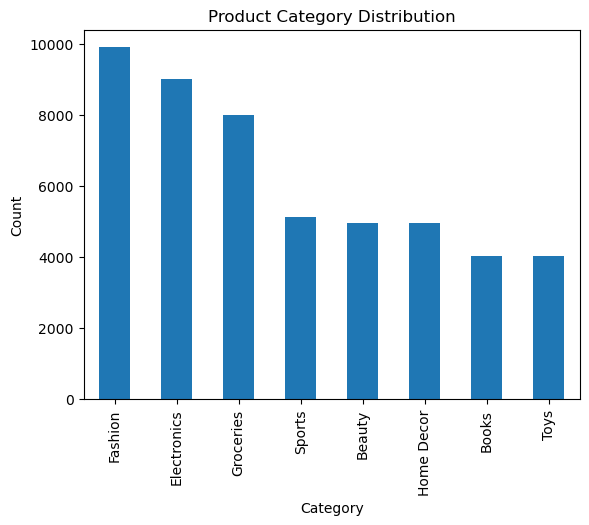

In [21]:

category_counts = df['Product_Category'].value_counts()

print(category_counts)

category_counts.plot(kind='bar')
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()



### Insight
Categories with higher sales can receive more marketing focus and inventory investment.



# 3. Does Discount Increase Spending?


In [8]:

discount_analysis = df.groupby('Discount_Applied')['Purchase_Amount'].mean()

print(discount_analysis)


Discount_Applied
No     2063.278183
Yes    2405.646035
Name: Purchase_Amount, dtype: float64



### Inferential Insight
If average spending is higher with discounts, Amazon can strategically use offers during sales seasons.



# 4. Does Delivery Time Affect Ratings?


In [23]:

correlation = df[['Delivery_Time_Days','Rating']].corr()

print(correlation)


                    Delivery_Time_Days    Rating
Delivery_Time_Days            1.000000 -0.674658
Rating                       -0.674658  1.000000


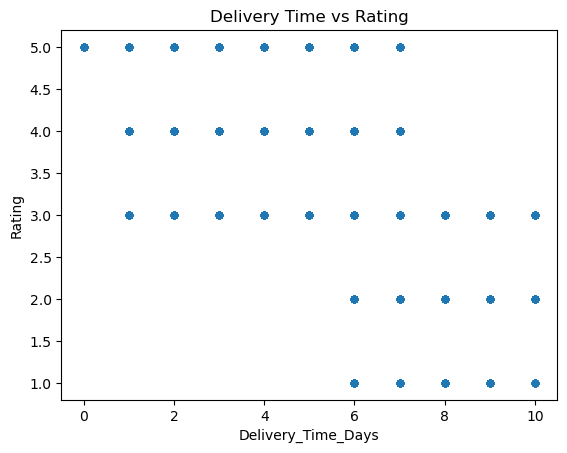

In [24]:

df.plot.scatter(x='Delivery_Time_Days', y='Rating')
plt.title("Delivery Time vs Rating")
plt.show()



### Business Insight
A negative relationship suggests slower deliveries reduce customer satisfaction.



# 5. Repeat Customer Analysis


In [25]:

repeat_analysis = df.groupby('Repeat_Customer')['Purchase_Amount'].mean()

print(repeat_analysis)


Repeat_Customer
No     1882.790224
Yes    2537.041685
Name: Purchase_Amount, dtype: float64



### Business Insight
Repeat customers are usually high-value customers and should be retained using loyalty programs.



# 6. Prime Member Analysis


In [26]:

prime_analysis = df.groupby('Prime_Member')['Purchase_Amount'].mean()

print(prime_analysis)


Prime_Member
No     2121.100872
Yes    2373.902087
Name: Purchase_Amount, dtype: float64



### Business Insight
Prime users often spend more and contribute significantly to revenue.



# 7. City-wise Revenue Analysis


City
Kolkata      14433056.81
Bangalore    14097220.55
Delhi        14047493.83
Mumbai       13913095.57
Hyderabad    13897962.76
Chennai      13840581.04
Ahmedabad    13754902.10
Pune         13732972.55
Name: Purchase_Amount, dtype: float64


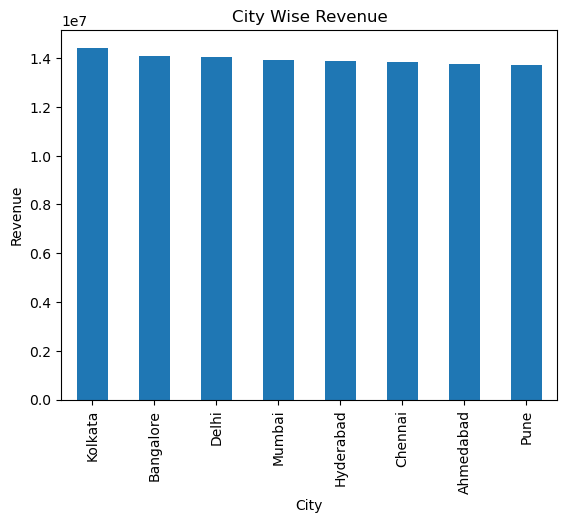

In [15]:

city_revenue = df.groupby('City')['Purchase_Amount'].sum().sort_values(ascending=False)

print(city_revenue)

city_revenue.plot(kind='bar')
plt.title("City Wise Revenue")
plt.ylabel("Revenue")
plt.show()



# 8. Customer Satisfaction Distribution


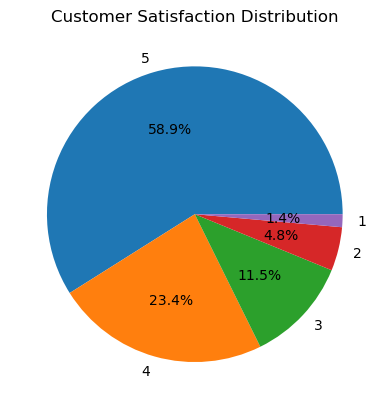

In [28]:

df['Satisfaction_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Satisfaction Distribution")
plt.ylabel("")
plt.show()



# 9. Hypothesis Testing Concept

## Business Assumption
"Discounts improve customer spending."

### Null Hypothesis (H0)
Discounts do NOT affect spending.

### Alternative Hypothesis (H1)
Discounts increase customer spending.


In [29]:
from scipy.stats import ttest_ind

In [30]:
discount_yes = df[df['Discount_Applied'] == 'Yes']['Purchase_Amount']

discount_no = df[df['Discount_Applied'] == 'No']['Purchase_Amount']

In [32]:
t_stat, p_value = ttest_ind(discount_yes, discount_no)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 30.762951525238087
P-Value: 6.900471877949845e-206


In [37]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Discounts significantly increase customer spending.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant evidence that discounts increase spending.")

Reject Null Hypothesis
Discounts significantly increase customer spending.



# Final Business Recommendations

## Recommendations to Amazon

1. Improve logistics in delayed delivery regions.
2. Offer targeted discounts to increase customer spending.
3. Focus on retaining repeat customers.
4. Improve customer experience for premium product buyers.
5. Expand Prime membership benefits.
6. Increase focus on high-performing categories.
